# Assignment III: Proteomic Classification of COVID-19 Severity
Nahia Urra López de Heredia (nahia.urra01@estudiant.upf.edu)

Last update: 26 March, 2026

- Exercise 1
- Exercise 2
- Exercise 3
- Session Info

## EXERCISE 1

### Build a Random Forest model to classify COVID-19 severity

Using the training cohort provided in Supplementary Table 3, build a Random Forest classification model similar to the one in the publication to distinguish between non-Severe and Severe COVID-19 patients.

Report the following performance metrics from cross-validation:
- Confusion matrix
- Accuracy
- ROC curve and AUC

How well does the Random Forest model separate non-Severe from Severe patients based on proteomic profiles?


#### Import Required Libraries-Packages

In [ ]:
import os
import numpy as np
import pandas as pd
import random
import pickle
from pathlib import Path

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay, classification_report)
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical, Real
from sklearn.base import clone

import matplotlib.pyplot as plt
import seaborn as sns

#### Reproducibility

In [56]:
# Set global seeds for reproducibility
random.seed(42)
np.random.seed(42)

In [ ]:
# Get working directory
CWD = Path.cwd()
print(CWD)

### Data Loading {.unlisted .unnumbered}

#### Read raw data {.unlisted .unnumbered}

In [58]:
# Get raw training proteomic features 
train_feat = pd.read_excel(f"{CWD}/data/mmc3.xlsx", sheet_name="Prot_and_meta_matrix", header=None)
# Get raw test proteomic features 
test_feat = pd.read_excel(f"{CWD}/data/mmc4.xlsx", sheet_name="Prot_and_meta_matrix", header=None)
# Get patients metadata (Group d --> Severity group)
labels = pd.read_excel(f"{CWD}/data/mmc1.xlsx", sheet_name="Clinical_information", header=0, usecols=["Patient ID a", "Group d"])


#### Filter training data {.unlisted .unnumbered}

In [59]:
# Get training protein IDs
train_feature_ids  = train_feat.iloc[2:793, 0]
# Get training gene symbols
train_gene_symbols = train_feat.iloc[2:793, 1]
# Get training sample IDs
train_sample_ids   = train_feat.iloc[1, 2:]
# Get log2-transformed training protein raw counts
train_values = train_feat.iloc[2:793, 2:].values.astype(float)

# Keep only primary gene name
train_gene_symbols = train_gene_symbols.fillna(train_feature_ids).str.split(',').str[0].values



In [60]:
# Check for duplicate protein IDs in training set
duplicates = train_feature_ids[train_feature_ids.duplicated(keep=False)]

if not duplicates.empty:
    print(f"Found {len(duplicates)} training duplicate IDs")
    print(duplicates.unique())
else:
    print("All training protein IDs are unique")

All training protein IDs are unique


In [61]:
# Create Mapping (protein id --> symbol) for training set 
gene_map_train = pd.DataFrame({'Gene Symbol': train_gene_symbols}, index=train_feature_ids.values)
print(gene_map_train.head())


       Gene Symbol
P04114        APOB
P01024          C3
P02768         ALB
P01023         A2M
P02751         FN1


In [62]:
# Create training dataframe (proteins as columns, samples as rows)
X_train = pd.DataFrame(train_values, index=train_feature_ids.values, columns=train_sample_ids.values)
X_train = X_train.T
X_train.index.name = 'Patient_ID'

print(X_train.head())

            P04114  P01024  P02768  P01023  P02751  P0C0L5  P0C0L4  P02787  \
Patient_ID                                                                   
XG1          1.535   1.243   0.904   0.742   1.687   0.923   1.280   0.945   
XG2          1.444   1.067   1.030   0.897   1.457   0.828   0.874   0.901   
XG3          1.245   1.166   0.940   0.799   0.805   2.302   1.867   0.838   
XG27         0.819   1.056   0.933   0.928   0.649   1.101   0.997   0.867   
XG26         1.136   1.079   0.925   0.746   0.618   1.422   1.520   0.760   

            P00450  P08603  ...  Q8TB36  Q76MJ5  Q6DHV5  Q8IUL8  Q9UBX5  \
Patient_ID                  ...                                           
XG1          1.080   1.096  ...     NaN     NaN   1.507   0.913   0.778   
XG2          1.018   1.198  ...     NaN     NaN   1.018   1.081   0.799   
XG3          1.219   1.032  ...     NaN     NaN   1.031   0.837   0.983   
XG27         1.016   1.057  ...     NaN     NaN   0.981   1.362   1.133   
XG2

#### Filter test data {.unlisted .unnumbered}

In [63]:
# Get test protein IDs
test_feature_ids  = test_feat.iloc[2:744, 0]
# Get test gene symbols
test_gene_symbols = test_feat.iloc[2:744, 1]
# Get test sample IDs
test_sample_ids   = test_feat.iloc[1, 2:]
# Get log2-transformed test protein raw counts
test_values = test_feat.iloc[2:744, 2:].values.astype(float)

# Keep only primary gene name
test_gene_symbols = test_gene_symbols.fillna(test_feature_ids).str.split(',').str[0].values


In [64]:
# Check for duplicate protein IDs in test set
duplicates = test_feature_ids[test_feature_ids.duplicated(keep=False)]

if not duplicates.empty:
    print(f"Found {len(duplicates)} test duplicate IDs")
    print(duplicates.unique())
else:
    print("All test protein IDs are unique")

All test protein IDs are unique


In [65]:
# Create Mapping (protein id -> symbol) for test set 
gene_map_test = pd.DataFrame({'Gene Symbol': test_gene_symbols}, index=test_feature_ids.values)
print(gene_map_test.head())

       Gene Symbol
P04114        APOB
P01024          C3
P02768         ALB
P01023         A2M
P02787          TF


In [66]:
# Create test dataframe
X_test = pd.DataFrame(test_values, index=test_feature_ids.values, columns=test_sample_ids.values)
X_test = X_test.T
X_test.index.name = 'Patient_ID'
print(X_test.head())

            P04114  P01024  P02768  P01023  P02787  P02751  P0C0L5  P0C0L4  \
Patient_ID                                                                   
XG20         1.130   1.001   1.042   0.837   1.077   1.107   1.183   1.259   
XG21         1.280   1.371   0.813   0.941   0.863   0.967   0.983   0.861   
XG22         1.081   1.394   0.856   1.454   0.765   0.872   1.357   1.618   
XG44         1.070   1.125   0.928   1.035   0.872   0.705   1.236   1.304   
XG43         0.916   1.164   0.804   0.802   0.760   0.712   1.728   1.655   

            P08603  P00450  ...  Q5JXB2  P41271  Q6ZTR5  O95399  P20711  \
Patient_ID                  ...                                           
XG20         1.072   0.984  ...   1.140   0.986   1.193   0.827     0.0   
XG21         1.199   1.230  ...   0.806   0.854   0.620   1.176     0.0   
XG22         1.330   0.941  ...   0.872   0.773   0.788   1.141     0.0   
XG44         1.100   1.005  ...   1.158   0.679   0.751   1.030     0.0   
XG4

#### Feature Alignment {.unlisted .unnumbered}

There are 791 features in training set 742 in the test.
We retain only the **common** features present in both sets.

In [67]:
# Keep only common features (X_train ∩ X_test)
common_features = X_train.columns.intersection(X_test.columns)

print(f"Train features: {X_train.shape[1]}, Test features: {X_test.shape[1]}, Common: {len(common_features)}")

Train features: 791, Test features: 742, Common: 639


In [68]:
# Subset datasets 
X_train = X_train[common_features]
X_test  = X_test[common_features]

# Subset mapping 
gene_map = gene_map_train.loc[common_features]

print("After intersection")
print(f"Train features: {X_train.shape[1]}, Test features: {X_test.shape[1]}")


After intersection
Train features: 639, Test features: 639


#### Label Encoding {.unlisted .unnumbered}

Create binary labels 

- `Group` - `2` (non-Severe) → `0`  
- `Group` - `3` (Severe) → `1`

In [69]:
# Filter and create binary y-labels 
label_map = labels.set_index('Patient ID a')
print("> Group metadata:\n")
print(label_map.head())

y_train = label_map.loc[X_train.index, 'Group d'].map({2: 0, 3: 1}).rename('Severity')
print("\n> Training labels:\n")
print(y_train.head())
y_test  = label_map.loc[X_test.index, 'Group d'].map({2: 0, 3: 1}).rename('Severity')
print("\n> Test lables:\n")
print(y_test.head())

> Group metadata:

              Group d
Patient ID a         
XG1                 2
XG2                 2
XG3                 2
XG4                 2
XG5                 2

> Training labels:

Patient_ID
XG1     0
XG2     0
XG3     0
XG27    1
XG26    1
Name: Severity, dtype: int64

> Test lables:

Patient_ID
XG20    0
XG21    0
XG22    0
XG44    1
XG43    1
Name: Severity, dtype: int64


#### Logs on features, samples {.unlisted .unnumbered}

In [70]:
# print logs
print("\t (Samples, Features)")
print("X_train:", X_train.shape, "\ny_train:", y_train.shape)
print("\n")
print("X_test: ", X_test.shape,  "\ny_test: ", y_test.shape)
print("\n")
print("Value_counts:")

print("\ny_train:\n\n", y_train.value_counts())
print("\ny_test:\n\n", y_test.value_counts())

	 (Samples, Features)
X_train: (31, 639) 
y_train: (31,)


X_test:  (10, 639) 
y_test:  (10,)


Value_counts:

y_train:

 Severity
0    18
1    13
Name: count, dtype: int64

y_test:

 Severity
0    6
1    4
Name: count, dtype: int64


#### Check missing values {.unlisted .unnumbered}

In [71]:
# Count features with missing values in training and test 
print(f"Number of training features with NaN: {X_train.isna().any().sum()}")
print(f"Number of test features with NaN: {X_test.isna().any().sum()}")

Number of training features with NaN: 263
Number of test features with NaN: 0


#### Handle missing values {.unlisted .unnumbered}

In our case we have spectrometry-based proteomics, where missing values are predominantly **Missing Not At Random (MNAR)**. That is proteins below **Limit of Detection (LOD)** are not measured, and are not missing by chance.

Check samples for missing values
( to account for failed sample preparation or measurement run)

In [72]:
# Calculate what % of each patient's data is missing
samples_missing_ratio = X_train.isna().mean(axis=1)

# Look for samples with >70% of missing values
samples_missing = samples_missing_ratio[samples_missing_ratio > 0.7]

if samples_missing.empty:
    print(f"No samples with >70% missing data!")
else:
    print("The following samples have many missing values!")
    print(samples_missing)

No samples with >70% missing data!


Check features for missing values

In [73]:
missing = X_train.isna().mean()
missing = missing[missing > 0]

print("Missing values:\n")
print(f">80%: {(missing > 0.8).sum()} proteins")
print(f">70%: {(missing > 0.7).sum()} proteins")
print(f">50%: {(missing > 0.5).sum()} proteins")
print(f">30%: {(missing > 0.3).sum()} proteins")

Missing values:

>80%: 45 proteins
>70%: 45 proteins
>50%: 142 proteins
>30%: 211 proteins


The above missingness exploration revealed that 142 proteins (approx. 18% of the dataset) exceeded a 50% missingness rate. 

To prioritize biological signal over imputation artifacts, we removed these sparse features, to get in a finalized training matrix of [467] high-confidence proteins.

In [74]:
# Features with > 50% of missing values
features_to_drop = missing[missing > 0.5]

print("List of the 142 removed proteins:\n")
print(features_to_drop.index.values)
print("\nNames of these proteins:\n")
print(gene_map.loc[features_to_drop.index.values, "Gene Symbol"].values)


List of the 142 removed proteins:

['P01877' 'P0CF74' 'A0A0J9YVY3' 'P01767' 'P15924' 'A2NJV5' 'P35916'
 'P01699' 'P02538' 'P80748' 'Q86YZ3' 'P0DMV9' 'P31947' 'P69891' 'Q9UJJ9'
 'P32754' 'P01137' 'Q9NZT1' 'P20930' 'Q9Y646' 'P16930' 'Q15828' 'P19022'
 'P55774' 'O75356' 'P31151' 'P23141' 'P00352' 'P10586' 'P10619' 'P12821'
 'O15204' 'P07237' 'Q5D862' 'P05164' 'P28827' 'A0A075B6I1' 'P04792'
 'O43707' 'A0A0C4DH39' 'Q96RD9' 'P09382' 'Q8TDL5' 'P07307' 'P15907'
 'P50281' 'Q9UEW3' 'P62987' 'Q02413' 'O43505' 'Q8N6C8' 'P01854' 'O94985'
 'Q9HBR0' 'P23381' 'P27487' 'Q86UX7' 'P00533' 'Q53RT3' 'Q9P232' 'P05556'
 'Q9UBR2' 'A0A0A0MRZ9' 'P08174' 'A0A0C4DH24' 'P08670' 'P03973' 'O95810'
 'P10645' 'Q14623' 'P07900' 'P25789' 'P61916' 'O15394' 'P58335' 'P46531'
 'Q8IZF2' 'P08311' 'O43852' 'Q8WZ42' 'P30101' 'P0DP25' 'P49720' 'Q14574'
 'P37837' 'P36222' 'O60462' 'P16109' 'P14209' 'P20618' 'P58166' 'Q96S96'
 'P06744' 'Q92835' 'P13688' 'P61224' 'O75339' 'Q9UBQ6' 'P50552' 'P09467'
 'P26992' 'Q8TER0' 'A0A1B0GTC6' 

#### Remove proteins with > 50% missing values {.unlisted .unnumbered}

In [75]:
X_train = X_train.drop(columns=features_to_drop.index)
X_test = X_test[X_train.columns]
print(f"N.Features after removal = {X_train.shape[1]}")

N.Features after removal = 497


#### Imputation — MinProb {.unlisted .unnumbered}

Following the methodology of the paper, we assume that missingness in this TMT-labeled dataset is predominantly MNAR. Therefore, we implement MinProb imputation

For each protein, missing values are replaced by random draws from a Gaussian distribution centred at the 1st percentile of observed values, with a standard deviation of 30% of the observed std. 

In that way, low-intensity noise is simulated near the detection limit, rather than assuming complete absence.

$$x_{\text{imputed}} \sim \mathcal{N}(\mu_{q=0.01},\ \sigma_{\text{obs}} \times 0.3)$$

In [76]:
class MinProbImputer(BaseEstimator, TransformerMixin):
    """
    Minimum Probability (MinProb) imputer.

    Replaces missing values with random draws from a Gaussian distribution
    centred at the lower tail of each feature's observed intensity distribution.

    Parameters:

    q : float, default=0.01
        Quantile of the observed distribution used as the mean (mu) of the
        imputation Gaussian. q=0.01 targets the 1st percentile.

    scale : float, default=0.3
        Width of the imputation Gaussian, as a fraction of the
        observed standard deviation.

    random_state : int, default=42
        Seed for the random number generator.

    Attributes:
    mus_ : pd.Series
        Per-feature imputation means (q-th quantile of observed values).
        Shape: (n_features,). Set during fit().

    sigmas_ : pd.Series
        Per-feature imputation standard deviations (observed std * scale).

    rng_ : np.random.Generator
        Stateful random generator.

    """
    def __init__(self, q=0.01, scale=0.3, random_state=42):
        self.q = q
        self.scale = scale
        self.random_state = random_state

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        # Per-feature lower-tail mean: q-th percentile of observed (non-NaN) values
        self.mus_ = X.apply(lambda c: np.quantile(c.dropna(), self.q))
        # Get fraction of observed standard deviation
        self.sigmas_ = X.std() * self.scale
        # Initialise Random Generator once
        self.rng_ = np.random.default_rng(self.random_state)
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for i, col in enumerate(X.columns):
            mask = X[col].isnull()
            if mask.any():
                # Draw n_missing values from the low-intensity Gaussian
                X.loc[mask, col] = self.rng_.normal(
                    loc=self.mus_.iloc[i],
                    scale=max(self.sigmas_.iloc[i], 1e-6), # Floor sigma to avoid degenerate zero-variance distribution
                    size=mask.sum()
                )
        
        return X.values

#### Pipeline {.unlisted .unnumbered}

The full modelling pipeline consists of:

- `MinProbImputer`: Replace missing values with low-intensity noise
- `StandardScaler`: Centres to mean=0 and scales to unit variance (not necessary for RF model)
- `RandomForestClassifier`: Ensemble tree classifier

In [ ]:
# Define pipeline
pipeline = Pipeline([
    ('imputer', MinProbImputer(q=0.01, scale=0.3, random_state=42)),
    ('scaler',  StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

#### Define hyperparameter space for tuning

- `clf__n_estimators`: Number of trees
- `clf__max_depth`: Maximum depth of each tree
- `clf__min_samples_split`: Minimum n.samples to split node
- `clf__min_samples_leaf`: Minimum n.samples at leaf node
- `clf__max_features`: Fraction of features considered at each split
- `clf__class_weight`: Sample weighting strategy

In [78]:
# Define Hyperparameter Space
param_space = {
    'clf__n_estimators': Integer(50, 500),
    'clf__max_depth': Integer(3, 20),
    'clf__min_samples_split': Integer(2, 10),
    'clf__min_samples_leaf': Integer(1, 4),
    'clf__max_features': Real(0.01, 0.5),
    'clf__class_weight': Categorical([None, 'balanced'])
}

 #### Bayesian Search {.unlisted .unnumbered}

For the hyperparameter tuning we use **bayesian optimization**, that builds a surrogate model (**Gaussian Process**) of the **AUC** as a function of hyperparameters, directing subsequent evaluations towards promising regions of the search space.

**Cross-Validation**:

During the tuning we emploed `RepeatedStratifiedKFold`, with **10 Folds** and **5 repeats**.

Importanly, five repeats **reduce split variance sufficiently** to compare candidates, **without** the **computational overhead** of much more repeats.

All fitting steps are applied **within each cross-validation fold** to prevent data leakage from validation samples!

In [79]:
# Initialise Optimization procedure
search = BayesSearchCV(
    estimator=pipeline,
    search_spaces=param_space,
    n_iter=100,
    scoring='roc_auc',
    cv=RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42),
    n_jobs=-1,
    random_state=42,
    verbose=0
)

#### Model Training {.unlisted .unnumbered}

In [80]:
X_tr = X_train.values
y_tr = y_train.values

# Fit the pipeline
search.fit(X_tr, y_tr)

print("Best params:", search.best_params_)
print("Best CV AUC:", search.best_score_.round(3))

Best params: OrderedDict({'clf__class_weight': 'balanced', 'clf__max_depth': 20, 'clf__max_features': 0.08823745634797722, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 3, 'clf__n_estimators': 64})
Best CV AUC: 0.925


- The best combination of hyperparameters are shown above
- These hyperparameters gave a mean CV AUC of **0.925**
- The best estimator is refitted in the entire dataset

#### Cross-Validated Performance Evaluation {.unlisted .unnumbered}

To get per-sample predictions for every training sample we implement  a **manual accumulation loop**

1. For each of the 1000 folds (10 splits × 100 repeats), we fit a cloned pipeline on the training fold
2. Predict probabilities on the validation fold
3. Accumulate predictions across all repeats
4. Average accumulated probabilities

Here we use 100 repeats to reduce split variance substantially for all training samples.

In [81]:
# Get best pipeline
best_pipeline = search.best_estimator_

# Define cross-validation 
cv_repeats = RepeatedStratifiedKFold(n_splits=10, n_repeats=100, random_state=42)

# Setup accumulator for predicted Severe probabilities per sample
prob_accumulator = np.zeros(len(y_tr))
# Counts how many times each sample has been in a test fold
sample_counts = np.zeros(len(y_tr))

for train_idx, test_idx in cv_repeats.split(X_tr, y_tr):
    # Create new unfitted pipeline
    pipe = clone(best_pipeline)
    # Fit full pipeline
    pipe.fit(X_tr[train_idx], y_tr[train_idx])
    # Predict probability of Severe in validation fold
    prob_accumulator[test_idx] += pipe.predict_proba(X_tr[test_idx])[:, 1]
    # Count sample's predictions 
    sample_counts[test_idx] += 1

# Average predicted probabilities across all repeats
y_pred_prob = prob_accumulator / sample_counts
# Convert probabilities to binary
y_pred = (y_pred_prob >= 0.5).astype(int)


In [82]:
# Get unbiased cross-validated performance metrics
acc = accuracy_score(y_tr, y_pred)
cm = confusion_matrix(y_tr, y_pred)
fpr, tpr, _ = roc_curve(y_tr, y_pred_prob)
roc_auc = auc(fpr, tpr)

print(f"\nAccuracy: {acc:.3f}")
print(f"AUC: {roc_auc:.3f}")
print(f"\nConfusion Matrix:\n{cm}")


Accuracy: 0.839
AUC: 0.910

Confusion Matrix:
[[16  2]
 [ 3 10]]


#### Plot confusion matrix and ROC curve {.unlisted .unnumbered}

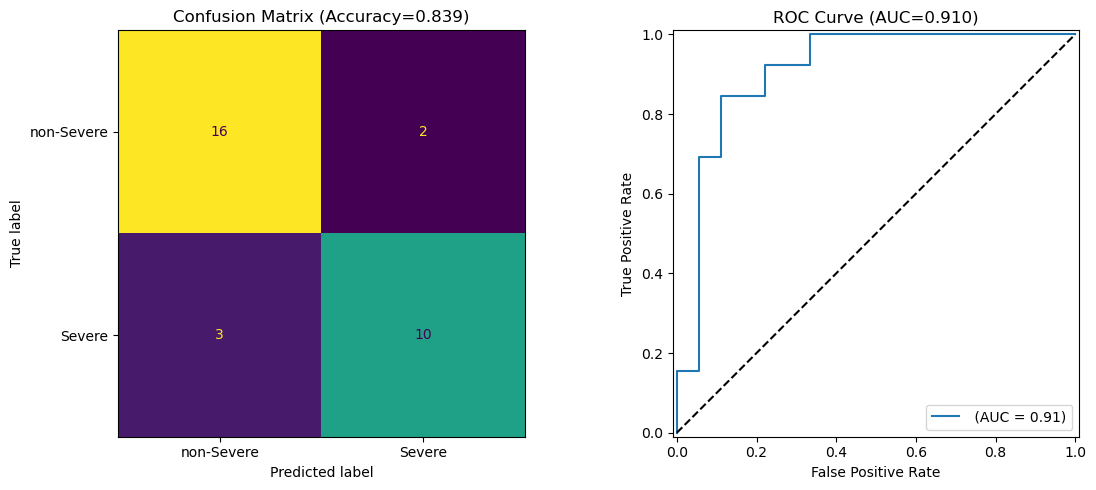

In [104]:
if not os.path.exists('figures'):
    os.makedirs('figures')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
ConfusionMatrixDisplay(cm, display_labels=['non-Severe', 'Severe']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix (Accuracy={acc:.3f})')

# ROC curve
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=axes[1], name="")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title(f'ROC Curve (AUC={roc_auc:.3f})')

plt.tight_layout()
plt.savefig('figures/cv_performance.png', dpi=150)
plt.show()

The model had:

- AUC: 0.91 (the model ranks Severe patient higher than the non-Severe patient in 91% of the times)
- Accuracy: 0.839 (26/31 samples correctly classified)
- Confusion matrix:  2 false positives, 3 false negatives (of highest cinical importance are the false negatives)

#### Save Model and Results {.unlisted .unnumbered}

In [84]:
if not os.path.exists("results"):
    os.makedirs("results")
    
with open('results/search_results.pkl', 'wb') as f:
    pickle.dump({'search': search, 'y_pred': y_pred, 
                 'y_pred_prob': y_pred_prob}, f)

## EXERCISE 2

**Identify and interpret the most important features**

Using the trained Random Forest model from Exercise 1, identify the 25 most important protein features contributing to the classification. Disccus their biological relevance.

Compare your selected features to the proteins reported by the authors in Supplementary Table 5.


#### Feature Importance {.unlisted .unnumbered}

**Identify and interpret the most important features**


As with the RF model, we get the most important for the prediction featues based on the:

- **Mean Decrease in Impurity (MDI)**

The higher the MDI, the more discriminative the feature.

In [85]:
# Load model
with open('results/search_results.pkl', 'rb') as f:
    results = pickle.load(f)

search = results['search']
best_pipeline = search.best_estimator_

In [88]:
# Extract feature importances from best pipeline
best_rf = best_pipeline.named_steps['clf']
feature_names = X_train.columns  # protein ids

importances = pd.Series(best_rf.feature_importances_, index=feature_names)
top25 = importances.nlargest(25).sort_values(ascending=True)

# Map to gene symbols
top25_df = pd.DataFrame({
    'Importance': top25,
    'Gene Symbol': gene_map.loc[top25.index, 'Gene Symbol']
})

print("Top 25 proteins\n")
print(top25_df.sort_values('Importance', ascending=False))

Top 25 proteins

        Importance Gene Symbol
P0DJI8    0.066268        SAA1
P02741    0.064129         CRP
Q9UK55    0.057220   SERPINA10
P00338    0.041563        LDHA
P05452    0.038059      CLEC3B
P02743    0.033030        APCS
P12259    0.030955          F5
P0DJI9    0.030823        SAA2
P06396    0.029080         GSN
P05155    0.027247    SERPING1
P13671    0.025406          C6
P51884    0.023974         LUM
P01009    0.023779    SERPINA1
P22692    0.022276      IGFBP4
P01011    0.020344    SERPINA3
P04004    0.017585         VTN
P00738    0.014174          HP
Q14766    0.014058       LTBP1
P02748    0.013966          C9
P02787    0.013252          TF
O95479    0.012430        H6PD
P06702    0.012159      S100A9
P13796    0.011607        LCP1
P07360    0.011607         C8G
Q6UX71    0.011229      PLXDC2


In [101]:
# Load top features as indentified in paper
mmc5_raw = pd.read_excel('data/mmc5.xlsx', sheet_name='Prot_and_meta_matrix', header=None)

# Get protein IDs and gene symbols
paper_feature_ids = mmc5_raw.iloc[2:24, 0].values
paper_gene_symbols = mmc5_raw.iloc[2:24, 1].values

print("Paper's 22 important proteins:")
print(paper_gene_symbols)

# Overlap with our top 25
our_proteins  = set(top25_df['Gene Symbol'].tolist())
paper_proteins_set = set(paper_gene_symbols)

overlap = our_proteins & paper_proteins_set
only_ours = our_proteins - paper_proteins_set
only_paper  = paper_proteins_set - our_proteins

print(f"\nOverlap: {len(overlap)}/22 paper proteins found in our top 25")
print(f"Shared: {sorted(overlap)}")
print(f"Only ours: {sorted(only_ours)}")
print(f"Only in paper: {sorted(only_paper)}")

Paper's 22 important proteins:
['HP' 'CFB' 'SERPINA3' 'CRP' 'C9' 'LRG1' 'ALB' 'SERPING1' 'CLEC3B' 'SAA1'
 'SAA2' 'F5' 'C6' 'LCP1' 'CPN1' 'LBP' 'LUM' 'ITIH3' 'HABP2' 'OAF'
 'PGLYRP2' 'SERPINA10']

Overlap: 13/22 paper proteins found in our top 25
Shared: ['C6', 'C9', 'CLEC3B', 'CRP', 'F5', 'HP', 'LCP1', 'LUM', 'SAA1', 'SAA2', 'SERPINA10', 'SERPINA3', 'SERPING1']
Only ours: ['APCS', 'C8G', 'GSN', 'H6PD', 'IGFBP4', 'LDHA', 'LTBP1', 'PLXDC2', 'S100A9', 'SERPINA1', 'TF', 'VTN']
Only in paper: ['ALB', 'CFB', 'CPN1', 'HABP2', 'ITIH3', 'LBP', 'LRG1', 'OAF', 'PGLYRP2']


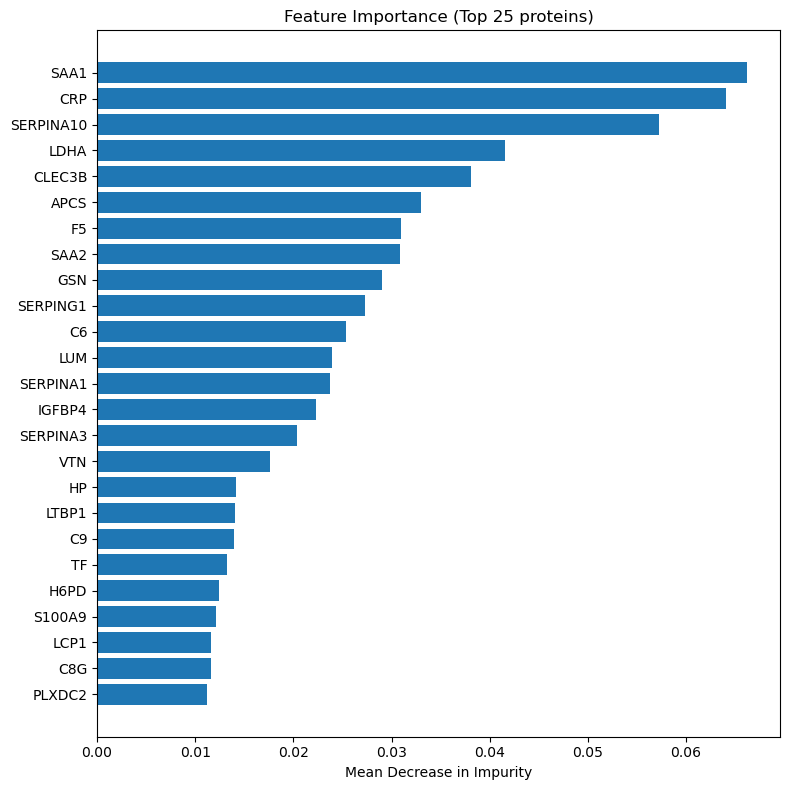

In [103]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(8, 8))

bars = ax.barh(top25_df['Gene Symbol'], top25_df['Importance'])
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Feature Importance (Top 25 proteins)')
plt.tight_layout()
plt.savefig('figures/top25_proteins.png', dpi=150)
plt.show()

Discrepancies between our top 25 important proteins and those reported in the paper may be due to:

- **Different importance metric**:

    They may have use *mean decrease in accuracy* (permutation-based) instead of *mean decrease in impurity* (MDI).

- **Different feature set**:
    
    They trained using proteins + metabolites, our model was based on only the proteomic profiles.

-  **Different model configurations**

**Importantly:**

We identified the upregulated proteins (**SAA1**, **SAA**, **CRP**), that are known to be potential biomarkers for viral infections. Actually, CRP already been associated with COVID-19.

Also, **C6**, that is a part of the complement membrane attack complex, has significant influence in eliminating invading pathogens [^1].

On top of that, but elevated total LDH activity (**LDHA**) is strongly associated with severe COVID‑19 and is widely used as a prognostic marker [^2].

Furthermore, **CLEC3B** is involved in fibrinolysis, tissue remodeling, and cardiovascular disease. Several omics studies implicate it as a biomarker linked to COVID‑19 severity, mainly through decreased plasma levels in severe cases [^3].

[^1]: Shen B, et al. Proteomic and Metabolomic Characterization of COVID-19 Patient Sera. Cell. 2020 Jul 9;182(1):59-72.e15. doi: 10.1016/j.cell.2020.05.032. Epub 2020 May 28. PMID: 32492406; PMCID: PMC7254001.

[^2]: Fialek B, et al. (2022). Diagnostic value of lactate dehydrogenase in COVID-19: A systematic review and meta-analysis. *Cardiol J.* 29(5):751-758. doi: 10.5603/CJ.a2022.0056.

[^3]: Li Y, et al. Multi-platform omics analysis reveals molecular signature for COVID-19 pathogenesis, prognosis and drug target discovery. Signal Transduct Target Ther. 2021 Apr 15;6(1):155. doi: 10.1038/s41392-021-00508-4. PMID: 33859163; PMCID: PMC8047575.


## EXERCISE 3

### External prediction on an independent test cohort

Using the final Random Forest model trained on the full training cohort, predict disease severity for patients in the independent test cohort provided in Supplementary Table 4.

Your task is to:

-   Apply the trained model to the test cohort.  
-   Obtain predicted probabilities of Severe disease for each patient.  
-   Assign predicted class labels based on these probabilities.  
-   Compare predictions to the true clinical labels.  


How does the model perform on the independent test cohort?


Accuracy: 0.700
AUC: 0.833

Confusion Matrix:
[[4 2]
 [1 3]]

Classification Report:
              precision    recall  f1-score   support

  non-Severe       0.80      0.67      0.73         6
      Severe       0.60      0.75      0.67         4

    accuracy                           0.70        10
   macro avg       0.70      0.71      0.70        10
weighted avg       0.72      0.70      0.70        10

Patient ID  True Label  Predicted  Prob Severe  Correct
      XG20           0          0        0.109     True
      XG21           0          0        0.453     True
      XG22           0          1        0.562    False
      XG44           1          1        0.828     True
      XG43           1          1        0.859     True
      XG23           0          0        0.109     True
      XG24           0          0        0.062     True
      XG25           0          1        0.766    False
      XG46           1          1        0.609     True
      XG45           1      

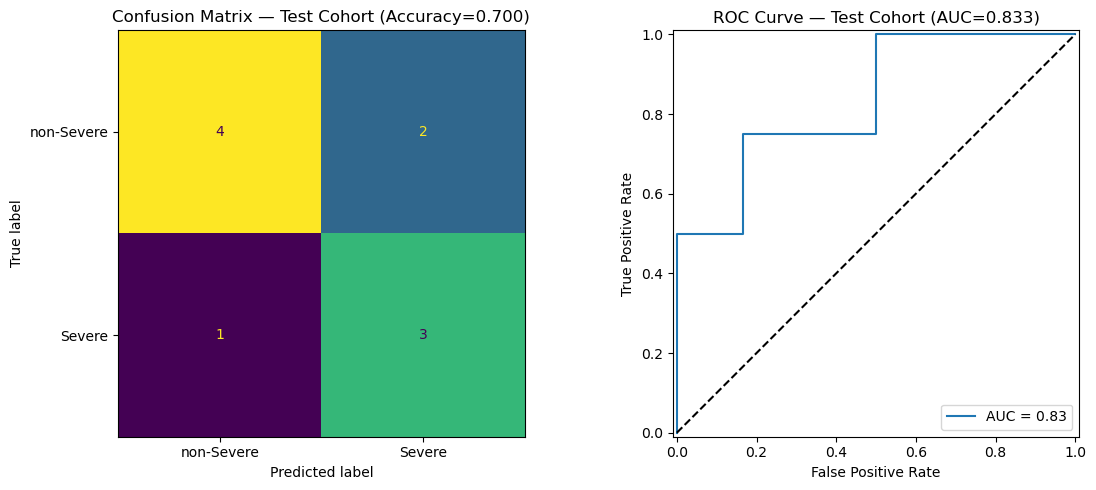

In [105]:
# Predict on test set
X_te = X_test.values
y_te = y_test.values

# Get predicted labels
y_test_pred = best_pipeline.predict(X_te)
# Get predicted probabilities
y_test_pred_prob = best_pipeline.predict_proba(X_te)[:, 1]

# Get model performance on the test set
acc = accuracy_score(y_te, y_test_pred)
auc_sc = roc_auc_score(y_te, y_test_pred_prob)
cm = confusion_matrix(y_te, y_test_pred)
fpr, tpr, _ = roc_curve(y_te, y_test_pred_prob)

print(f"Accuracy: {acc:.3f}")
print(f"AUC: {auc_sc:.3f}")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nClassification Report:\n{classification_report(y_te, y_test_pred, target_names=['non-Severe', 'Severe'])}")

# Create report with prediction for each pantient
results_df = pd.DataFrame({
    'Patient ID':    X_test.index,
    'True Label':    y_te,
    'Predicted':     y_test_pred,
    'Prob Severe':   y_test_pred_prob.round(3),
    'Correct':       y_te == y_test_pred
})
print(results_df.to_string(index=False))

# Plots Confusion Matrix and ROC Curve of test set
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm, display_labels=['non-Severe', 'Severe']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix — Test Cohort (Accuracy={acc:.3f})')

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_sc).plot(ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title(f'ROC Curve — Test Cohort (AUC={auc_sc:.3f})')

plt.tight_layout()
plt.savefig('figures/test_performance.png', dpi=150)
plt.show()

### Expected Performance Considerations {.unlisted .unnumbered}

The paper reported 7/10 correct classifications on this cohort (C2), noting three clinically explainable misclassifications:

- **XG45** (Severe → predicted non-Severe): 20+ days of traditional       Chinese medicine pre-admission may have normalised serum biomarker profiles
- **XG22** (non-Severe → predicted Severe): chronic HBV infection and diabetes complicating the molecular signature  
- **XG25** (non-Severe → predicted Severe): no clear clinical explanation provided

The drop in performance from training CV (AUC ≈ 0.91) to external test (AUC≈ 0.833) is expected given the small cohort size (n=10) and known confounders.

## SESSION INFO

In [106]:
import session_info
session_info.show()